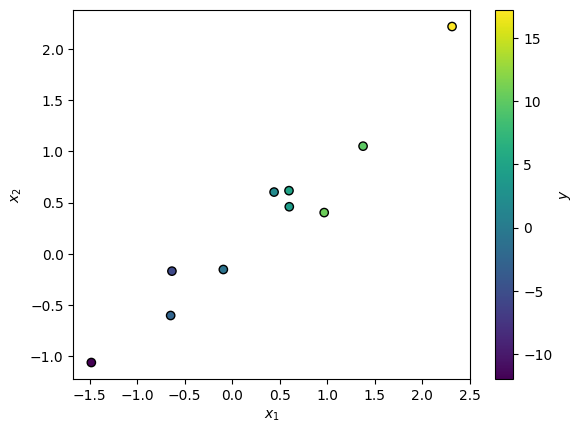

In [46]:
import numpy as np
from matplotlib import pyplot as plt

rng = np.random.default_rng(0)

sigma_x = np.array([[1, 0.9],
                    [0.9, 1]])
mean_x = np.array([0, 0])
beta = np.array([10, -2])
sigma_y = 2.0
n = 10

x = rng.multivariate_normal(mean_x, sigma_x, size=n)
y = x@beta + rng.normal(0, sigma_y, size=n)

sc = plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='black')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.colorbar(sc, label='$y$')
plt.show()

In [50]:
alpha = 0.1
beta_ml = np.linalg.solve(x.T @ x, x.T @ y)
beta_ridge = np.linalg.solve(x.T @ x + alpha*np.eye(2), x.T @ y)
beta_ps = beta_ml / (1 + alpha)
beta_ml, beta_ridge, beta_ps

(array([11.30525084, -4.42608895]),
 array([ 9.53808178, -2.36844875]),
 array([10.27750076, -4.02371723]))

/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_15993/3848526960.py:33: RuntimeWarning: divide by zero encountered in matmul
  residuals = y[:, None] - x @ B_grid.T
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_15993/3848526960.py:33: RuntimeWarning: overflow encountered in matmul
  residuals = y[:, None] - x @ B_grid.T
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_15993/3848526960.py:33: RuntimeWarning: invalid value encountered in matmul
  residuals = y[:, None] - x @ B_grid.T
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_15993/3848526960.py:38: RuntimeWarning: divide by zero encountered in matmul
  true_risk = (np.sum((diff @ sigma_x) * diff, axis=1) + sigma_y**2).reshape(B1.shape)
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_15993/3848526960.py:38: RuntimeWarning: overflow encountered in matmul
  true_risk = (np.sum((diff @ sigma_x) * diff, axis=1) + sigma_y**2).reshape(B1.shape)
/var/folders/zw/qxvhv2ms1rx684818_y1cvl

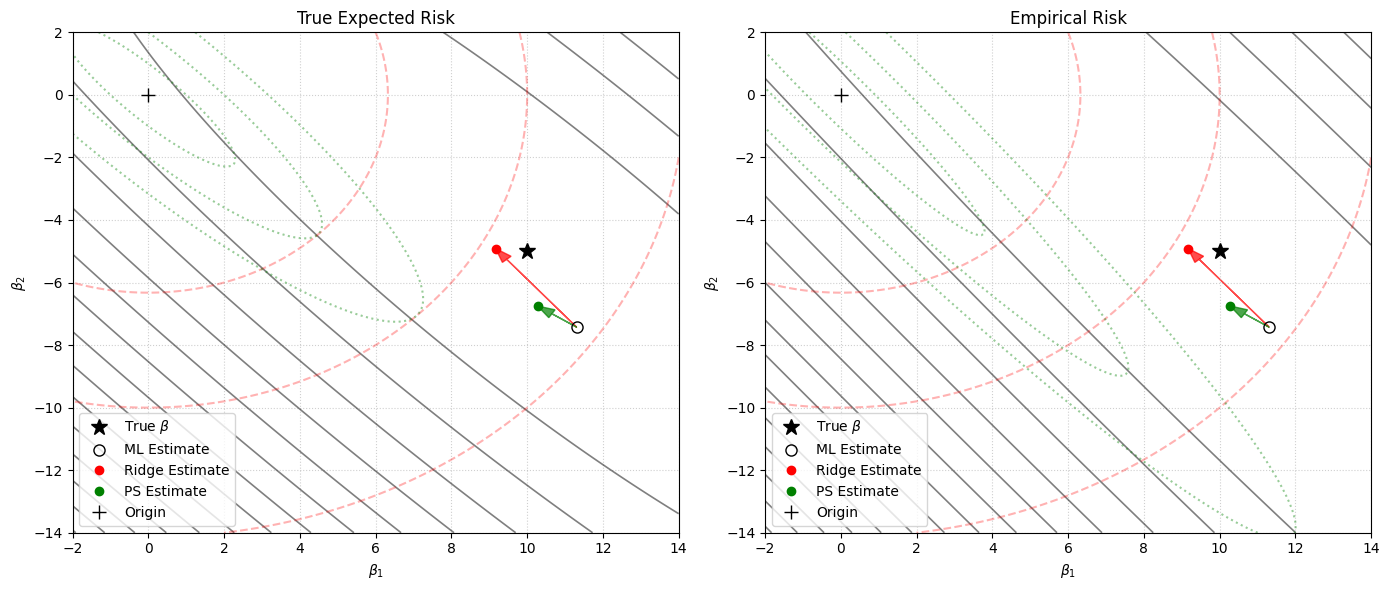

In [60]:
import numpy as np
from matplotlib import pyplot as plt

# 1. Setup and Data Generation
rng = np.random.default_rng(0)

sigma_x = np.array([[1, 0.9],
                    [0.9, 1]])
mean_x = np.array([0, 0])
beta_true = np.array([10, -5])
sigma_y = 2.0
n = 10

x = rng.multivariate_normal(mean_x, sigma_x, size=n)
y = x @ beta_true + rng.normal(0, sigma_y, size=n)

# Alpha values configured to make the shrinkage paths visually distinct
alpha_ridge = 0.1
alpha_ps = 0.1

beta_ml = np.linalg.solve(x.T @ x, x.T @ y)
beta_ridge = np.linalg.solve(x.T @ x + alpha_ridge * np.eye(2), x.T @ y)
beta_ps = beta_ml / (1 + alpha_ps)

# 2. Grid Creation covering the origin and the estimates
b1_range = np.linspace(-2, 14, 200)
b2_range = np.linspace(-14, 2, 200)
B1, B2 = np.meshgrid(b1_range, b2_range)
B_grid = np.c_[B1.ravel(), B2.ravel()]

# 3. Calculate Risks
# Empirical Risk
residuals = y[:, None] - x @ B_grid.T
empirical_risk = np.sum(residuals**2, axis=0).reshape(B1.shape)

# True Risk
diff = B_grid - beta_true
true_risk = (np.sum((diff @ sigma_x) * diff, axis=1) + sigma_y**2).reshape(B1.shape)

# 4. Calculate Penalty Contours (for visualization overlaid on the risk)
ridge_penalty = (B1**2 + B2**2)
ps_penalty_true = np.sum((B_grid @ sigma_x) * B_grid, axis=1).reshape(B1.shape)
ps_penalty_emp = np.sum((B_grid @ (x.T @ x / n)) * B_grid, axis=1).reshape(B1.shape)

# 5. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_landscape(ax, risk, ps_penalty, title):
    # Risk Contours (solid black lines)
    ax.contour(B1, B2, risk, levels=15, colors='black', alpha=0.5, linewidths=1.2)
    
    # Penalty Contours (dashed lines)
    ax.contour(B1, B2, ridge_penalty, levels=[40, 100, 200], colors='red', alpha=0.3, linestyles='dashed')
    ax.contour(B1, B2, ps_penalty, levels=[1, 4, 10], colors='green', alpha=0.4, linestyles='dotted')

    # Estimates
    ax.plot(*beta_true, 'k*', markersize=12, label='True $\\beta$')
    ax.plot(*beta_ml, 'ko', fillstyle='none', markersize=8, label='ML Estimate')
    ax.plot(*beta_ridge, 'ro', markersize=6, label='Ridge Estimate')
    ax.plot(*beta_ps, 'go', markersize=6, label='PS Estimate')
    ax.plot(0, 0, 'k+', markersize=10, label='Origin')

    # Shrinkage vectors
    ax.arrow(beta_ml[0], beta_ml[1], beta_ridge[0]-beta_ml[0], beta_ridge[1]-beta_ml[1], 
             color='red', head_width=0.3, length_includes_head=True, alpha=0.7)
    ax.arrow(beta_ml[0], beta_ml[1], beta_ps[0]-beta_ml[0], beta_ps[1]-beta_ml[1], 
             color='green', head_width=0.3, length_includes_head=True, alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel(r'$\beta_1$')
    ax.set_ylabel(r'$\beta_2$')
    ax.legend(loc='lower left')
    ax.grid(True, linestyle=':', alpha=0.6)

plot_landscape(axes[0], true_risk, ps_penalty_true, 'True Expected Risk')
plot_landscape(axes[1], empirical_risk, ps_penalty_emp, 'Empirical Risk')

plt.tight_layout()
plt.show()